# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



# Assignment Answer 

## Imports

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## Load Datasets

In [35]:
all_df = pd.read_excel("alldata.xlsx")
elected_df = pd.read_excel("electeddata.xlsx")

drq_df = pd.read_excel("drq.xlsx")
tv2q_df = pd.read_excel("tv2q.xlsx")

print("All candidates:", all_df.shape)
print("Elected candidates:", elected_df.shape)

display(all_df.head())
display(drq_df.head())
display(tv2q_df.tail(24))


All candidates: (867, 53)
Elected candidates: (169, 53)


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


,ID,Title,Question,Info,ArgumentFor,ArgumentAgainst,WordMerger,ID_CandidateQuestionType,Rule,QuestionListData
0,530,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,NaN,Den kollektive trafik bør være billig og tilgæ...,Det er dyrt for statskassen at opretholde drif...,0,1,FT,NaN
1,531,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,NaN,Historisk rammer kriser de fattigste hårdest. ...,Det danske samfund er et af de mest lige samfu...,0,1,FT,NaN
2,533,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...,NaN,Den mest effektive måde at stoppe bandekrimina...,"Det er urimeligt, at den samme forbrydelse ska...",0,1,FT,NaN
3,534,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,NaN,"Så længe Danmark er medlem af EU, kan flertall...",Danmark er bedst tjent med at være en del af E...,0,1,FT,NaN
4,535,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år...",NaN,Ruslands angreb på Ukraine har ændret alting o...,Vi er medlemmer af Nato og har i forvejen et s...,0,1,FT,NaN


,id,type,header,question,depends
50,1a,rate,Miljø og klima,"Oksekød bør pålægges en klimaafgift, således a...",NaN
51,1b,rate,Miljø og klima,"De virksomheder, der udleder mest CO₂, skal be...",NaN
52,2a,rate,Hospitaler og sundhed,Folketinget bør afsætte midler målrettet et lø...,NaN
53,2b,rate,Hospitaler og sundhed,Cigaretter bør pålægges en ekstra afgift på 20...,NaN
54,3a,rate,Udenrigs- og forsvarspolitik,Danmark bør bruge to procent af BNP på forsvar...,NaN
55,3b,rate,Udenrigs- og forsvarspolitik,Ulandsbistanden bør hæves.,NaN
56,4a,rate,Økonomi,Den økonomiske ulighed i det danske samfund bø...,NaN
57,4b,rate,Økonomi,Staten bør i højere grad kompensere danskerne ...,NaN
58,5a,rate,Ældre,Det er nødvendigt at indføre brugerbetaling i ...,NaN
59,5b,rate,Ældre,Der bør tilføres ekstra ressourcer til ældrepl...,NaN


## Define party colors

In [36]:
party_colors = {
    "Socialdemokratiet": "#b72722",
    "Radikale Venstre": "#7b3f8c",
    "Det Konservative Folkeparti": "#9ec420",
    "Nye Borgerlige": "#075864",
    "Socialistisk Folkeparti": "#e0007a",
    "Liberal Alliance": "#2ec4c7",
    "Kristendemokraterne": "#bfbfbf",
    "Moderaterne": "#6f35e8",
    "Dansk Folkeparti": "#f4d03f",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#00d66b",
    "Venstre": "#00749e",
    "Danmarksdemokraterne": "#83b9ef",
    "Enhedslisten": "#f58214",
    "Alternativet": "#2d963f",
    "Løsgænger": "#666666",
}



## Data cleaning and feature preparation

In [37]:
all_df_clean = all_df.copy()
elected_df_clean = elected_df.copy()

all_df_clean["alder"] = all_df_clean["alder"].replace(0, np.nan)
elected_df_clean["alder"] = elected_df_clean["alder"].replace(0, np.nan)

meta_cols = ["navn", "parti", "storkreds", "alder"]
feature_cols = [col for col in all_df_clean.columns if col not in meta_cols]

dr_cols = [col for col in feature_cols if col.isdigit()]
tv2_cols = [col for col in feature_cols if not col.isdigit()]

X_all = all_df_clean[feature_cols]
X_elected = elected_df_clean[feature_cols]

print("Number of response features:", len(feature_cols))
print("DR questions:", len(dr_cols))
print("TV2 questions:", len(tv2_cols))

print("Missing response values in all candidates:", X_all.isna().sum().sum())
print("Missing response values in elected candidates:", X_elected.isna().sum().sum())

print("Response range:", X_all.min().min(), "to", X_all.max().max())


Number of response features: 49
DR questions: 25
TV2 questions: 24
Missing response values in all candidates: 0
Missing response values in elected candidates: 0
Response range: -2 to 2


#### Interpretation

The dataset is already mostly clean. There are no missing response values, no duplicated candidate names, and all response values are within the expected range from -2 to 2.

The only cleaning step is replacing age values equal to 0 with missing values, because age 0 is not meaningful for election candidates.

The response columns are separated from metadata columns because later analysis, such as PCA and clustering, should only use political answer variables.


## Question mapping

In [38]:
dr_questions = drq_df[["ID", "Title", "Question"]].copy()
dr_questions["feature"] = dr_questions["ID"].astype(str)
dr_questions["source"] = "DR"
dr_questions = dr_questions.rename(columns={
    "Title": "topic",
    "Question": "question"
})

tv2_questions = tv2q_df[tv2q_df["id"].isin(tv2_cols)][["id", "header", "question"]].copy()
tv2_questions["feature"] = tv2_questions["id"].astype(str)
tv2_questions["source"] = "TV2"
tv2_questions = tv2_questions.rename(columns={
    "header": "topic"
})

question_map = pd.concat([
    dr_questions[["feature", "source", "topic", "question"]],
    tv2_questions[["feature", "source", "topic", "question"]]
], ignore_index=True)

question_map = question_map.set_index("feature").loc[feature_cols].reset_index()

display(question_map.head())
display(question_map.tail())
print("Mapped questions:", len(question_map))

,feature,source,topic,question
0,530,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
1,531,DR,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...
2,533,DR,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...
3,534,DR,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU
4,535,DR,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år..."


,feature,source,topic,question
44,10b,TV2,Socialområdet,"Den såkaldte Arne-pension, der giver mulighed ..."
45,11a,TV2,Mink-sagen,Der har været alt for meget fokus på Mette Fre...
46,11b,TV2,Mink-sagen,"Det bør undersøges, om Mette Frederiksen kan s..."
47,12a,TV2,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ..."
48,12b,TV2,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ..."


Mapped questions: 49


### Interpretation

The response columns use technical question identifiers, so they are mapped back to their original question texts.

This mapping is important because later PCA loadings and party averages will refer to feature IDs. Without this step, it would be difficult to interpret which political issues define the main axes of variation.


## PCA political landscape


In [39]:
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_all_scaled)

pca_df = all_df_clean[["navn", "parti", "storkreds", "alder"]].copy()
pca_df["PC1"] = pca_result[:, 0]
pca_df["PC2"] = pca_result[:, 1]

print("Explained variance PC1:", round(pca.explained_variance_ratio_[0], 3))
print("Explained variance PC2:", round(pca.explained_variance_ratio_[1], 3))
print("Total explained variance:", round(pca.explained_variance_ratio_[:2].sum(), 3))

display(pca_df.head())


Explained variance PC1: 0.417
Explained variance PC2: 0.103
Total explained variance: 0.52


,navn,parti,storkreds,alder,PC1,PC2
0,Lars Philipsen Prahm,Moderaterne,Københavns Storkreds,78.0,-3.362185,-1.516930
1,Karsten Hønge,Socialistisk Folkeparti,Fyns Storkreds,64.0,6.091749,1.191952
2,Martin Kelleher-Petersen,Alternativet,Bornholms Storkreds,37.0,4.960182,-1.096007
3,Nicklas Gjedsig Larsen,Alternativet,Nordjyllands Storkreds,28.0,4.037529,0.834949
4,Tom Gillesberg,Løsgænger,Københavns Storkreds,58.0,0.506901,-0.784739


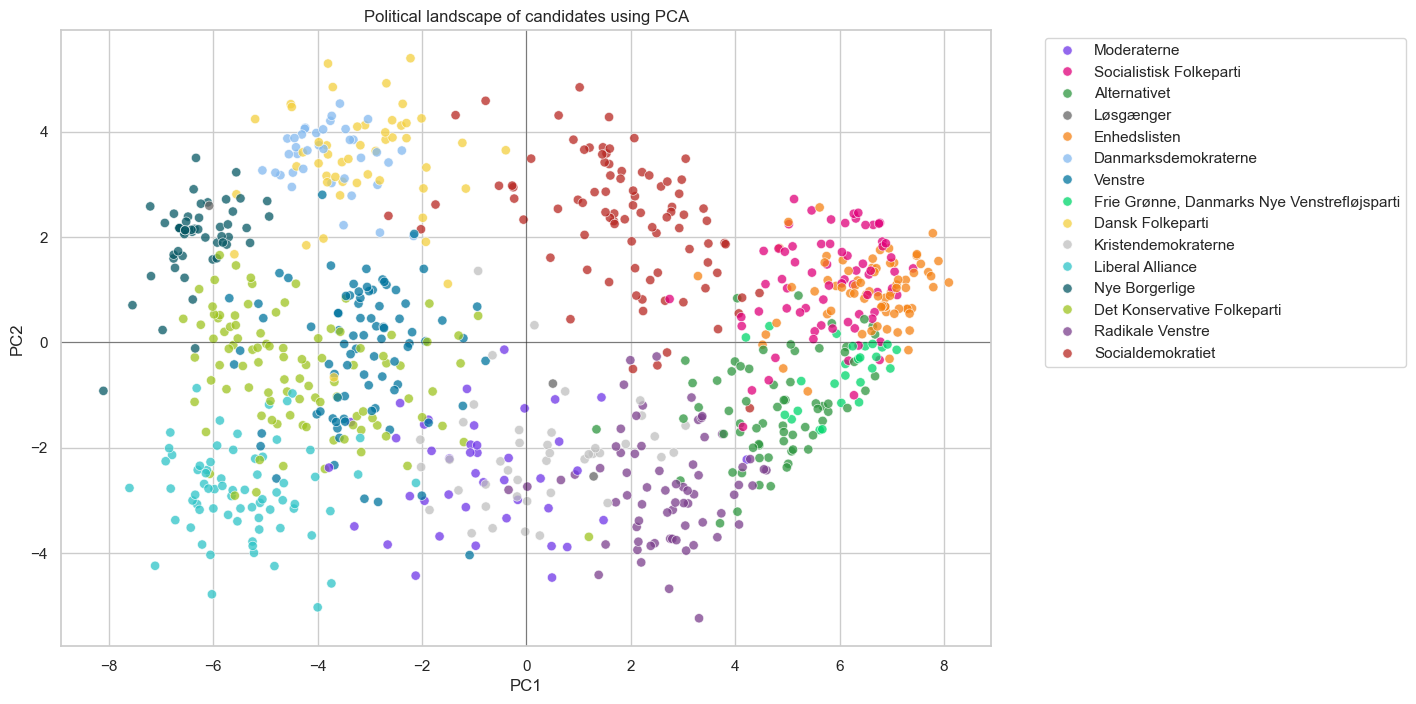

In [40]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="parti",
    palette=party_colors,
    alpha=0.75,
    s=45
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)
plt.title("Political landscape of candidates using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


### Interpretation

PCA reduces the 49 political response variables into two main dimensions. Each point represents one candidate, and candidates close to each other gave similar answers.

The plot gives a two-dimensional approximation of the political landscape. The explained variance tells us how much of the total variation in answers is captured by the first two principal components.


## PCA axis interpretation

In [41]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

loadings = loadings.reset_index().rename(columns={"index": "feature"})

loadings_with_questions = loadings.merge(
    question_map,
    on="feature",
    how="left"
)

pc1_important = loadings_with_questions.reindex(
    loadings_with_questions["PC1"].abs().sort_values(ascending=False).index
).head(10)

pc2_important = loadings_with_questions.reindex(
    loadings_with_questions["PC2"].abs().sort_values(ascending=False).index
).head(10)

display(pc1_important[["feature", "source", "topic", "question", "PC1"]])
display(pc2_important[["feature", "source", "topic", "question", "PC2"]])


,feature,source,topic,question,PC1
0,530,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,0.190641
5,537,DR,VELFÆRD,"Det er okay, at den økonomiske ulighed stiger,...",-0.190284
31,4a,TV2,Økonomi,Den økonomiske ulighed i det danske samfund bø...,0.188849
30,3b,TV2,Udenrigs- og forsvarspolitik,Ulandsbistanden bør hæves.,0.188778
15,550,DR,ARBEJDSMARKED OG ØKONOMI,"Der skal indføres kvoter, der sikrer mindst 30...",0.188555
1,531,DR,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,0.187016
9,543,DR,VELFÆRD,"Det er en god idé, at dagpengesatsen for nyudd...",-0.185893
14,548,DR,VELFÆRD,Der skal afsættes penge til at hjælpe kontanth...,0.176281
22,559,DR,KLIMA OG ENERGI,Danmark bør indføre CO2-afgift på flyrejser,0.176279
7,540,DR,VELFÆRD,Det skal være muligt at tjene penge på at driv...,-0.174404


,feature,source,topic,question,PC2
44,10b,TV2,Socialområdet,"Den såkaldte Arne-pension, der giver mulighed ...",0.302918
20,556,DR,ARBEJDSMARKED OG ØKONOMI,Den såkaldte Arne-pension skal afskaffes,-0.297979
16,551,DR,EU OG UDENRIGS,Der skal være permanent grænsekontrol mellem D...,0.293836
18,553,DR,UDDANNELSE,Der skal udflyttes flere uddannelsespladser fr...,0.272808
32,4b,TV2,Økonomi,Staten bør i højere grad kompensere danskerne ...,0.258449
33,5a,TV2,Ældre,Det er nødvendigt at indføre brugerbetaling i ...,-0.228295
35,6a,TV2,Flygtninge og indvandrere,Den danske udlændingepolitik er for stram.,-0.208142
36,6b,TV2,Flygtninge og indvandrere,Det vil være en god idé at etablere et dansk a...,0.207708
19,555,DR,EU OG UDENRIGS,Asylansøgere bør sendes til et land uden for E...,0.206750
3,534,DR,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,0.201447


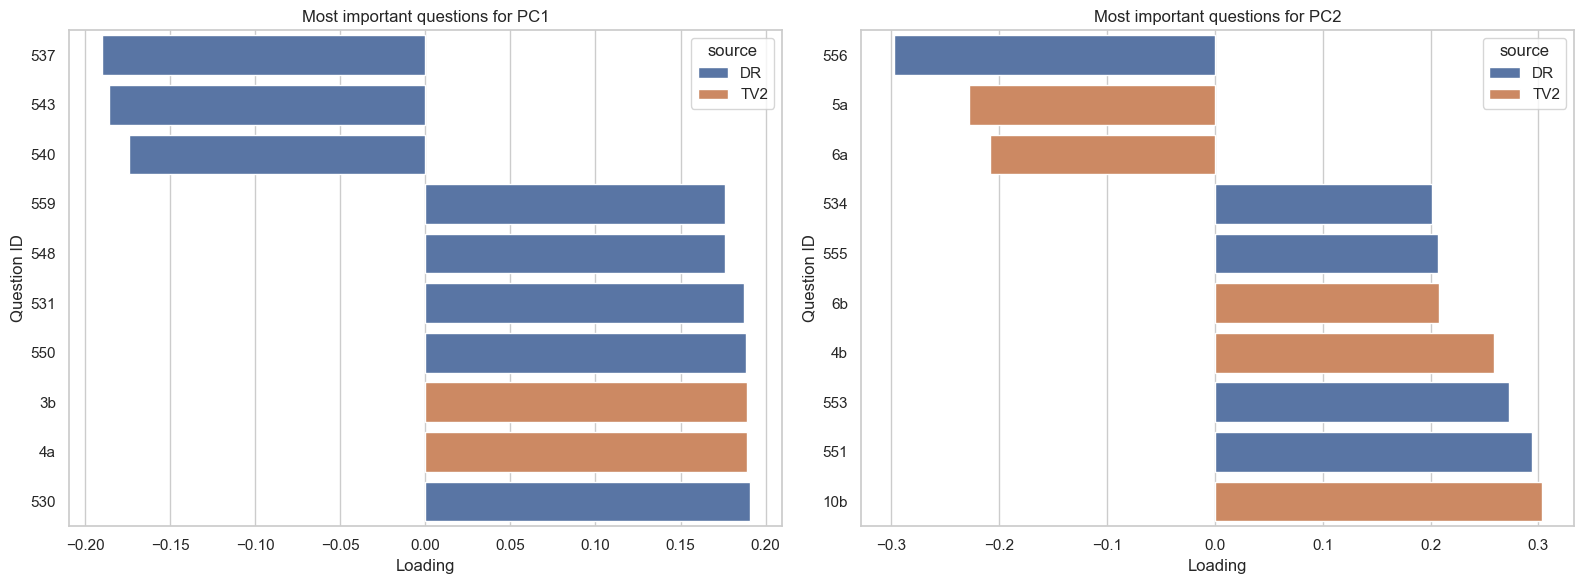

In [42]:
top_pc1 = pc1_important.sort_values("PC1")
top_pc2 = pc2_important.sort_values("PC2")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_pc1,
    x="PC1",
    y="feature",
    hue="source",
    dodge=False,
    ax=axes[0]
)
axes[0].set_title("Most important questions for PC1")
axes[0].set_xlabel("Loading")
axes[0].set_ylabel("Question ID")

sns.barplot(
    data=top_pc2,
    x="PC2",
    y="feature",
    hue="source",
    dodge=False,
    ax=axes[1]
)
axes[1].set_title("Most important questions for PC2")
axes[1].set_xlabel("Loading")
axes[1].set_ylabel("Question ID")

plt.tight_layout()
plt.show()


## Average party positions by question


In [43]:
party_question_avg = all_df_clean.groupby("parti")[feature_cols].mean()

party_question_avg_long = party_question_avg.reset_index().melt(
    id_vars="parti",
    var_name="feature",
    value_name="average_response"
)

party_question_avg_long = party_question_avg_long.merge(
    question_map,
    on="feature",
    how="left"
)

display(party_question_avg_long.head())
print("Rows:", len(party_question_avg_long))


,parti,feature,average_response,source,topic,question
0,Alternativet,530,1.880597,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
1,Danmarksdemokraterne,530,-0.837838,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
2,Dansk Folkeparti,530,-0.571429,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
3,Det Konservative Folkeparti,530,-0.836735,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
4,Enhedslisten,530,1.959459,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...


Rows: 735


In [44]:
selected_questions = pd.concat([
    pc1_important.head(3),
    pc2_important.head(3)
])["feature"].drop_duplicates().tolist()

selected_questions


['530', '537', '4a', '10b', '556', '551']

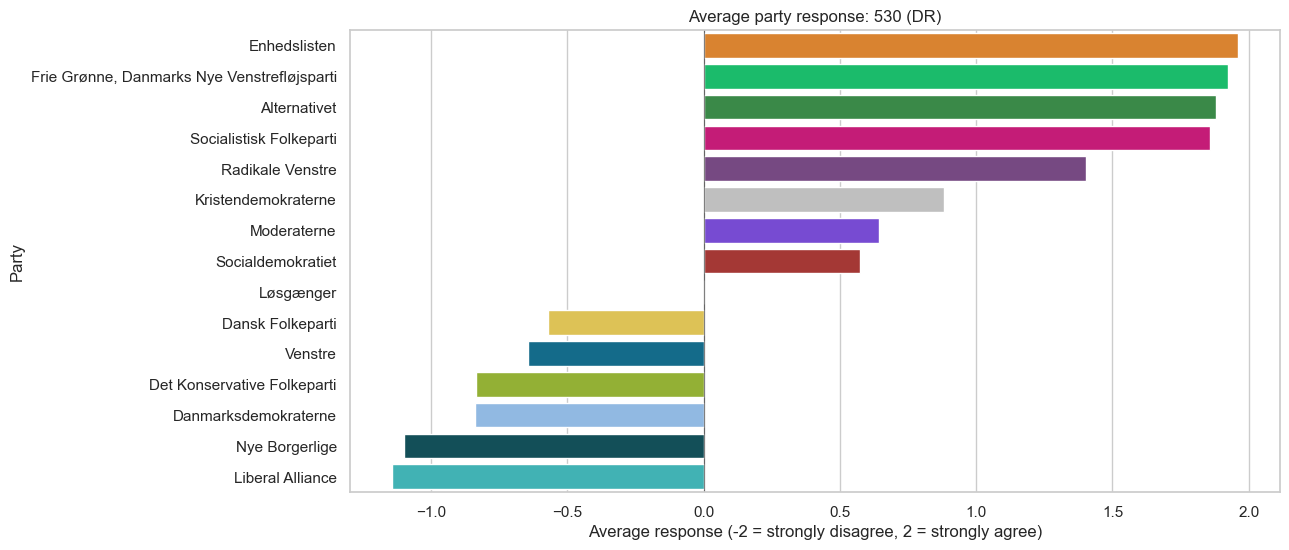

Danmark skal bruge flere penge på at styrke tog- og busdrift frem for at bygge nye motorveje



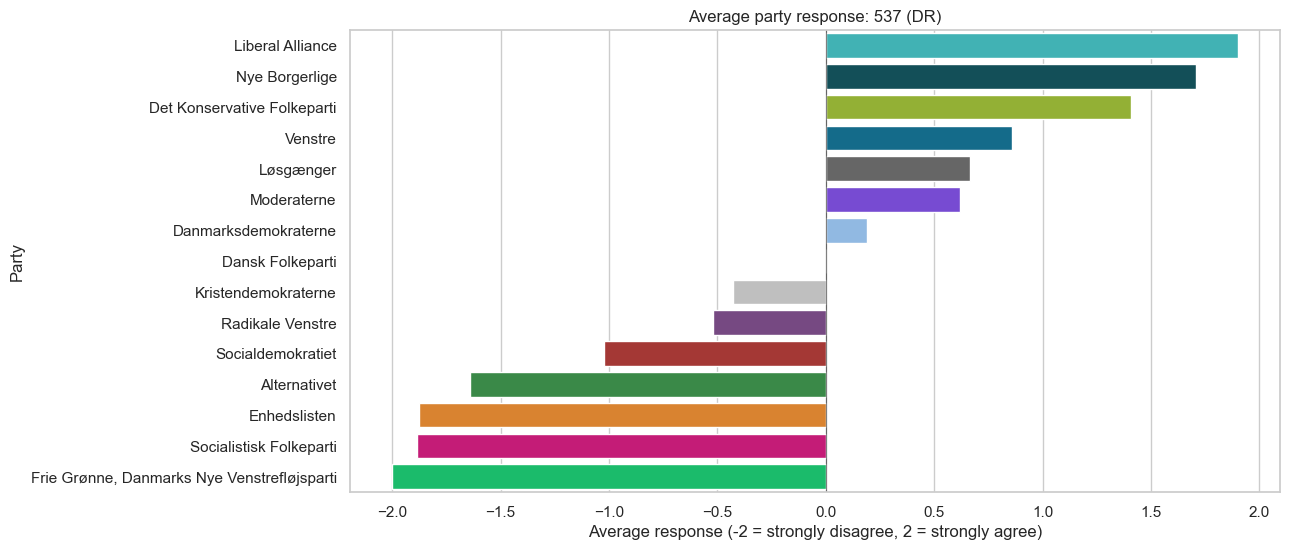

Det er okay, at den økonomiske ulighed stiger, så længe danskerne generelt bliver rigere



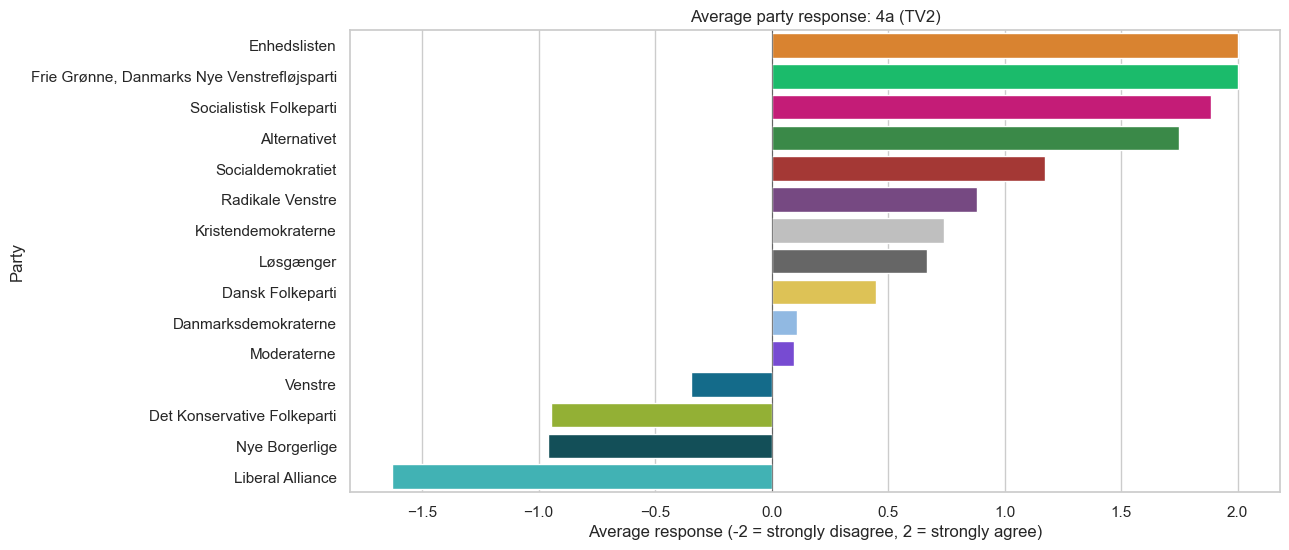

Den økonomiske ulighed i det danske samfund bør mindskes.



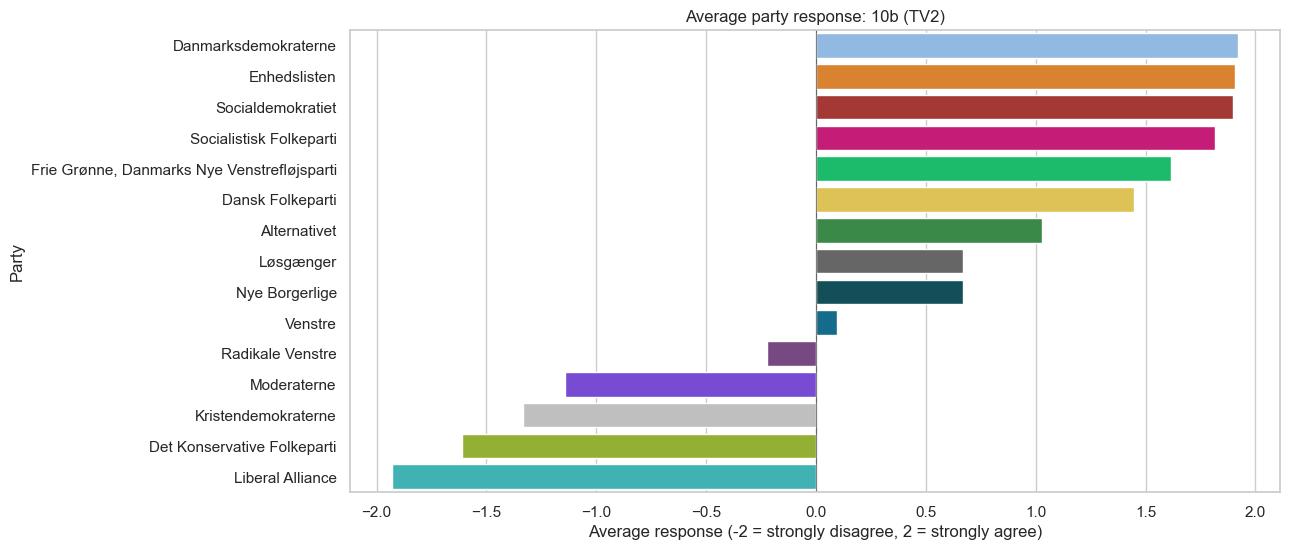

Den såkaldte Arne-pension, der giver mulighed for tidligere pension, skal bibeholdes, selvom der er mangel på arbejdskraft.



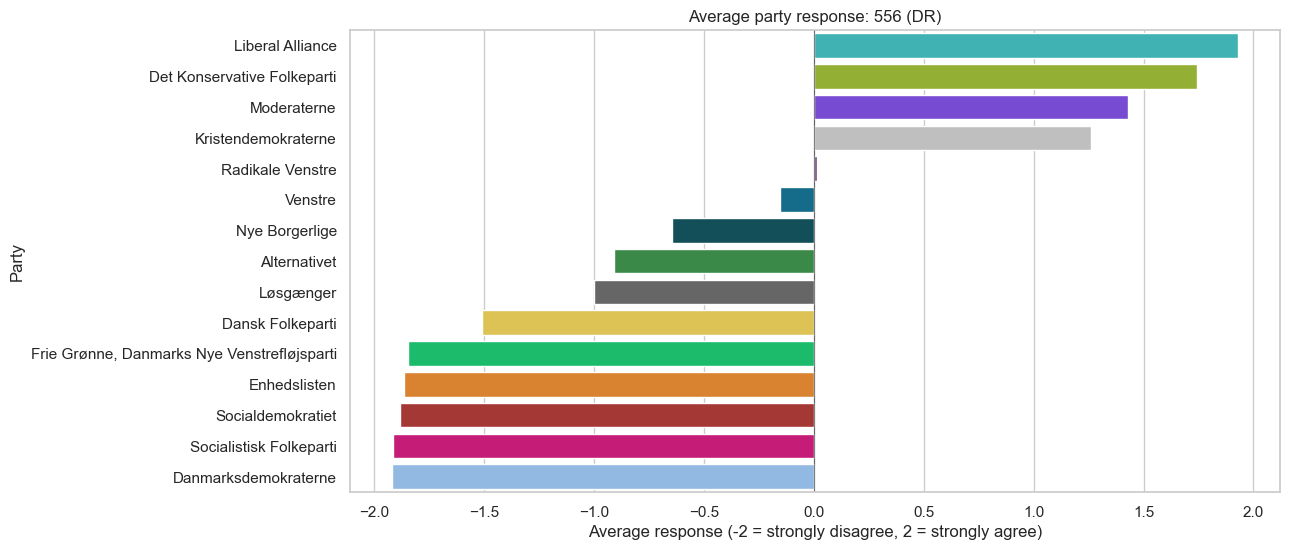

Den såkaldte Arne-pension skal afskaffes



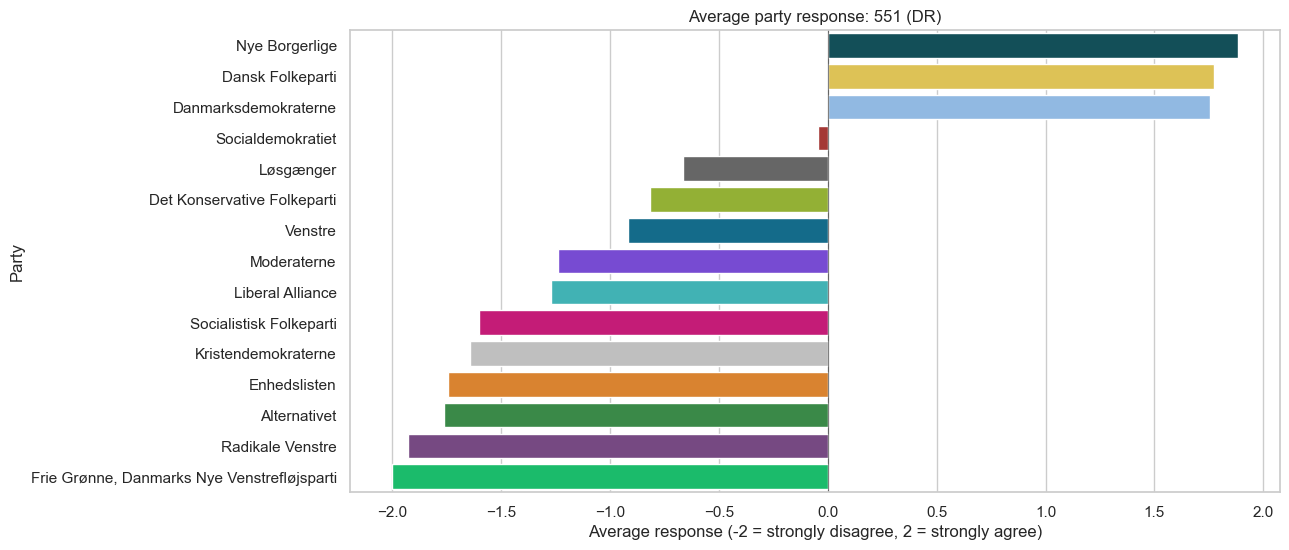

Der skal være permanent grænsekontrol mellem Danmark og Tyskland



In [ ]:
for feature in selected_questions:
    question_info = question_map[question_map["feature"] == feature].iloc[0]
    plot_data = party_question_avg_long[party_question_avg_long["feature"] == feature].sort_values(
        "average_response",
        ascending=False
    )

    print(question_info["question"])
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=plot_data,
        x="average_response",
        y="parti",
        hue="parti",
        palette=party_colors,
        legend=False
    )
    plt.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    plt.title(f"Average party response: {feature} ({question_info['source']})")
    plt.xlabel("Average response (-2 = strongly disagree, 2 = strongly agree)")
    plt.ylabel("Party")
    plt.show()

    print()


### Interpretation

The selected questions show clear party differences and support the PCA interpretation.

PC1 seems mainly related to welfare, inequality, redistribution, and climate policy. Left-wing and green parties are generally more supportive of public spending, reducing inequality, and climate-related policies, while liberal/right-wing parties are more sceptical.

PC2 seems more related to immigration, EU, border control, and welfare reform. Parties such as Nye Borgerlige, Dansk Folkeparti, and Danmarksdemokraterne stand out on border control, while parties such as Radikale Venstre, Frie Grønne, Alternativet, and Enhedslisten are strongly opposed.

Overall, the party averages confirm that the PCA axes reflect meaningful political divisions rather than random variation.